In [1]:
from utils import *
from model import *
from platesloader import *
import json
from old_unet import UNet
import pandas as pd

%matplotlib widget

# BBDM inpainting

In [2]:
diffusion = DiffusionHandler(timesteps=5, s=1e-4, objective='grad')

In [3]:
device = "cuda" if torch.cuda.is_available() else "xpu"

# 1. Setup Model (Smaller config for speed)
bbdm = DiffusionUNet(
    img_size=1024,
    img_channels=1,
    base_channels=16,
    channel_mults=(1, 2, 2, 2, 4, 4, 8), 
    attention_resolutions=(32, 16),
    time_emb_dim=128
).to(device)

# model.load_state_dict(torch.load('mymodel.pth', weights_only=True)) 
count_params(bbdm)

4.832.193 parameters


In [4]:
# model, diffusion, loss_history = train_diip(model, diffusion, epochs_on_plate=100)

In [6]:
RA_DEC_DEG = (148.96, 69.68)       # M82
RA_DEC_DEG = (10.6846, 41.2692)    # M31 (!)
RA_DEC_DEG = (23.4584, 30.6602)    # M33 (!)
# RA_DEC_DEG = (202.4696, 47.1953)   # M51  (fov .2)
# RA_DEC_DEG = (189.9975, -11.6231)  # M104
# RA_DEC_DEG = (189.0865, 25.9877)   # NGC 4565
# RA_DEC_DEG = (172.5292, 9.2764)    # NGC 3705
# RA_DEC_DEG = (145.5139, 0.3363)    # NGC 2967  (fov .05)

# random 
# ra = get_float(0, 360, 4)
# dec = get_float(-90, 90, 4)
# RA_DEC_DEG = (ra, dec) 

FOV_DEG = .15  
IMAGE_SIZE = bbdm.img_size  

In [7]:
SURVEY = 'PanSTARRS/DR1/r'        # Standard PS1 Red Band HiPS

# Download and get the NumPy array
raw = download_fits_as_numpy(
    survey_name=SURVEY,
    ra_deg=RA_DEC_DEG[0],
    dec_deg=RA_DEC_DEG[1],
    fov_deg=FOV_DEG,
    pixel_width=IMAGE_SIZE
)
y0 = fixnan(raw.copy())
# y0 = psf_image(y0, 3)

Querying HiPS survey: PanSTARRS/DR1/r at RA=23.4584, Dec=30.6602...
Image data successfully found in HDU index: 0
Download successful. Data shape: (1024, 1024)


Mean: -0.23685739934444427  STD: 0.3590069115161896


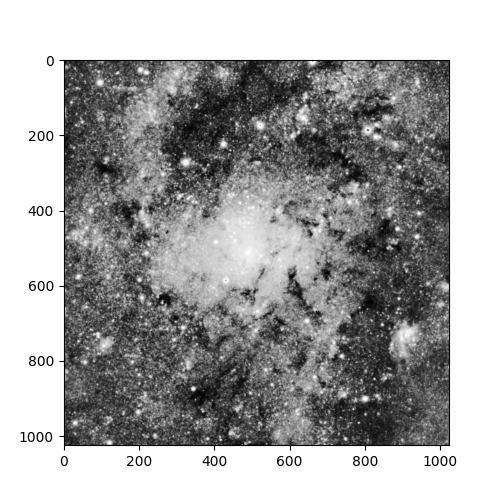

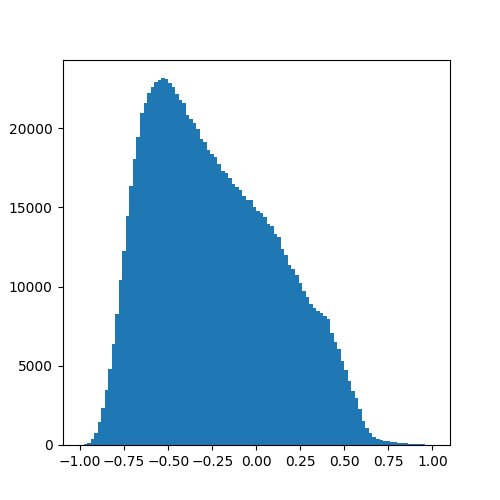

In [8]:
a = 1
y0s = np.arcsinh((y0 - np.median(y0)) / (a*y0.std()))
y0s -= y0s.min()
y0smax = y0s.max()
y0s /= y0smax
y0s *= 2
y0s -= 1
y = np2t(y0s).to(device).float()

image_d(t2np(y), cmap='gray')
hist(t2np(y))

In [9]:
SURVEY = 'CDS/P/SDSS9/r'        # Standard SDSS Red Band HiPS
SURVEY = 'CDS/P/DESI-Legacy-Surveys/DR10/r'

# Download and get the NumPy array
raw = download_fits_as_numpy(
    survey_name=SURVEY,
    ra_deg=RA_DEC_DEG[0],
    dec_deg=RA_DEC_DEG[1],
    fov_deg=FOV_DEG,
    pixel_width=IMAGE_SIZE
)

x0 = fixnan(raw.copy())

Querying HiPS survey: CDS/P/DESI-Legacy-Surveys/DR10/r at RA=23.4584, Dec=30.6602...
Image data successfully found in HDU index: 0
Download successful. Data shape: (1024, 1024)


Mean: -0.5830682516098022  STD: 0.26237913966178894


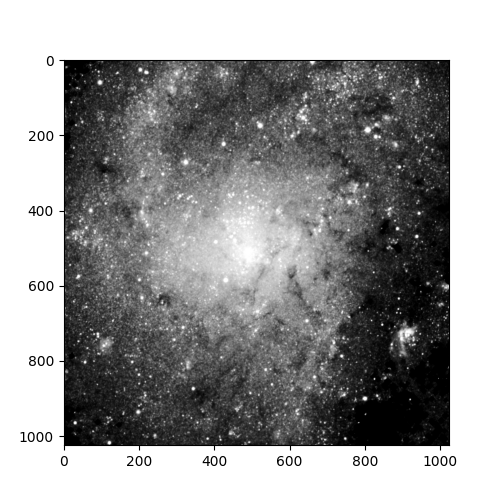

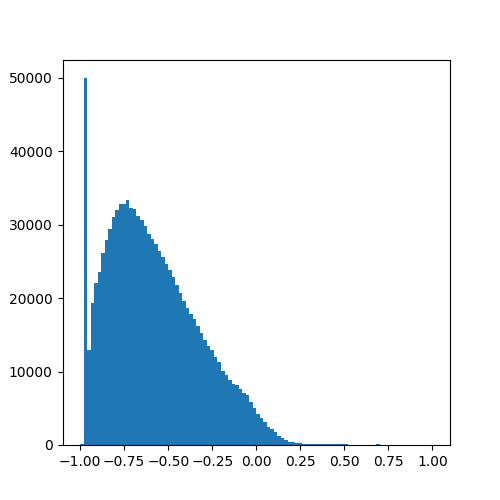

In [10]:
a = .25
x0s = np.arcsinh((x0 - np.median(x0)) / (a*x0.std()))
x0s -= x0s.min()
x0smax = x0s.max()
x0s /= x0smax
x0s *= 2
x0s -= 1
x = np2t(x0s).to(device)

image_d(x0s, contrast=.5, cmap='gray')
hist(x0s)

In [11]:
m = np.ones((IMAGE_SIZE, IMAGE_SIZE))
mx=910
my=740
mxw=120
myw=120
m[my - myw // 2:my + myw // 2, mx - mxw // 2:mx + mxw // 2] = 0 
mt = np2t(m).repeat(1, 1, 1, 1).float().to(device)

gt = x * (1-mt)
x *= mt

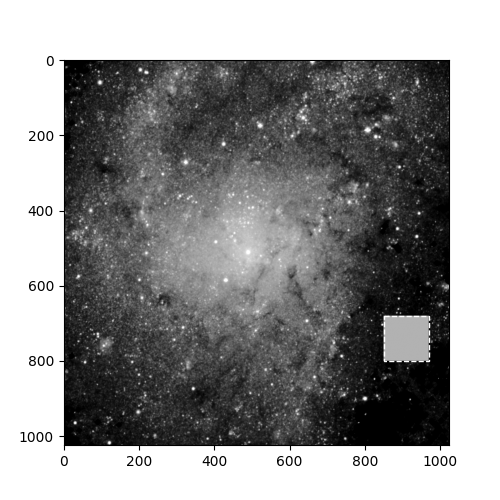

In [12]:
image_d(t2np(x), mx=mx, my=my, mw=mxw, cmap='gray', color='white') 

In [36]:
# --- Training --- 
diffusion, loss_history, latent = train_one_image( 
    bbdm, x, mask=mt, fixed_x_T=y, gt=gt,
    epochs=4000, 
    lr_unet=2e-4, 
    weight_decay=1e-4, 
    diffusion_handler=diffusion, 
    plot_interval=100, 
    interactive_plot=False 
) 

Continuing training with EXISTING BBDM handler. Objective: 'grad', Fixed s=0.0001
Latent 'y' provided. Using as FIXED conditioning.
Regularization ENABLED on UNet: WD_MAX=1.00e-04 -> WD_MIN=1.00e-06


Training (grad):   0%|          | 0/4000 [00:00<?, ?it/s]

Training Complete. Fixed s: 0.0001


In [ ]:
# torch.save(model.state_dict(), './mymodel.pth')   

In [37]:
# --- Sampling --- 
bbdm_restored = t2np(diffusion.sample(bbdm, y, sample_steps=5))[0] 

Sampling (grad):   0%|          | 0/5 [00:00<?, ?it/s]

In [38]:
# save_img(t2np(x)[0], './imgs/m33_2_masked.png', cmap='gray')

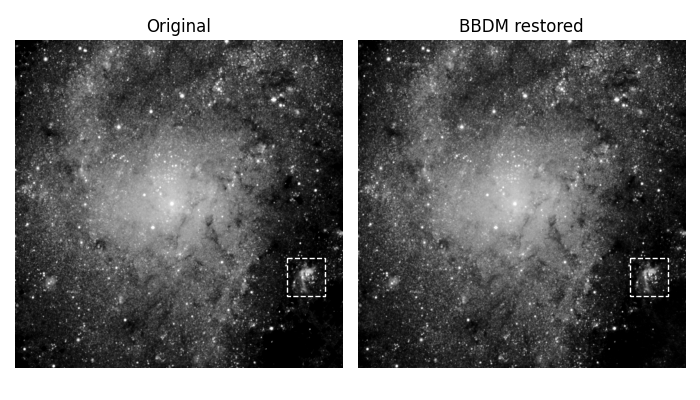

In [39]:
zscale = ZScaleInterval(contrast=.25)
# z1, z2 = zscale.get_limits(restored)
z1, z2 = zscale.get_limits(t2np(x))

# image_d(restored, mx=mx, my=my, mw=mxw, cmap='gray', vmin=z1, vmax=z2)   
# save_img(restored, './imgs/m33_2_restored.png', vmin=z1, vmax=z2, cmap='gray') 

fig, axs = plt.subplots(1, 2, figsize=(7, 4))
rect1 = patches.Rectangle((mx - mxw // 2, my - mxw // 2), 
                                 mxw, mxw, linewidth=1, 
                                 edgecolor='white', facecolor='none', 
                                 ls='--', fill=None)

rect2 = patches.Rectangle((mx - mxw // 2, my - mxw // 2), 
                                 mxw, mxw, linewidth=1, 
                                 edgecolor='white', facecolor='none', 
                                 ls='--', fill=None)

ax1 = axs[0]
ax1.add_patch(rect1)
ax1.imshow(x0s, cmap='gray', vmin=z1, vmax=z2) 
ax1.set_title('Original') 
ax1.axis('off') 

ax2 = axs[1]
ax2.add_patch(rect2)
ax2.imshow(bbdm_restored, cmap='gray', vmin=z1, vmax=z2)
ax2.set_title('BBDM restored') 
ax2.axis('off') 

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Layout to prevent title overlap
plt.show()

(np.float64(-0.5), np.float64(119.5), np.float64(119.5), np.float64(-0.5))

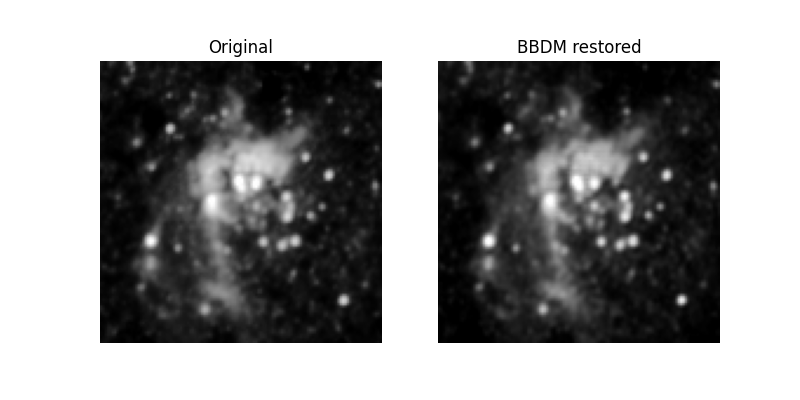

In [40]:
# ref_crop = t2np(y)[0, my-mxw//2:my+mxw//2, mx-mxw//2:mx+mxw//2]
restored_crop = bbdm_restored[my-mxw//2:my+mxw//2, mx-mxw//2:mx+mxw//2]
orig_crop = x0s[my-mxw//2:my+mxw//2, mx-mxw//2:mx+mxw//2]

fig, axs = plt.subplots(1, 2, figsize=(8, 4))

ax1 = axs[0]
ax1.imshow(orig_crop, cmap='gray', vmin=z1, vmax=z2) 
ax1.set_title('Original') 
ax1.axis('off') 

ax2 = axs[1]
ax2.imshow(restored_crop, cmap='gray', vmin=z1, vmax=z2)
ax2.set_title('BBDM restored') 
ax2.axis('off') 

# image_d(ref_crop, vmin=ref_z1, vmax=ref_z2, cmap='gray', ws=4)
# save_img(ref_crop, './imgs/m33_2_ref_crop.png', vmin=ref_z1, vmax=ref_z2, cmap='gray') 

In [68]:
# ref = y0s
# image_d(ref, mx=mx, my=my, mw=mxw, cmap='gray', ws=5) 
# save_img(ref, './imgs/m33_2_ref.png', cmap='gray') 

# Unet inpainting

In [22]:
unet = UNet(n_layers=8, fmaps=16, output='none').to(device)
count_params(unet)

3.401.825 parameters


In [24]:

# --- Training --- 
n_epochs = 2000
loss_history = []
param_groups = [
        {'params': unet.parameters(), 'lr': 1e-2, 'weight_decay': 1e-4, 'name': 'UNet'}
    ]
    
optimizer = torch.optim.Adam(param_groups)
pbar = tqdm(range(n_epochs), desc=f"Training (grad)", position=0, leave=False)
unet.train() 

for step_in_phase in pbar:

    optimizer.zero_grad() 
    out = unet(y)
    loss = F.mse_loss(out * mt, x * mt)

    postfix_dict = {
            "loss": f"{loss.item():.5f}"
        }
            
    pbar.set_postfix(postfix_dict)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

In [31]:
# --- Sampling ---   
unet_restored = t2np(unet(y))[0]

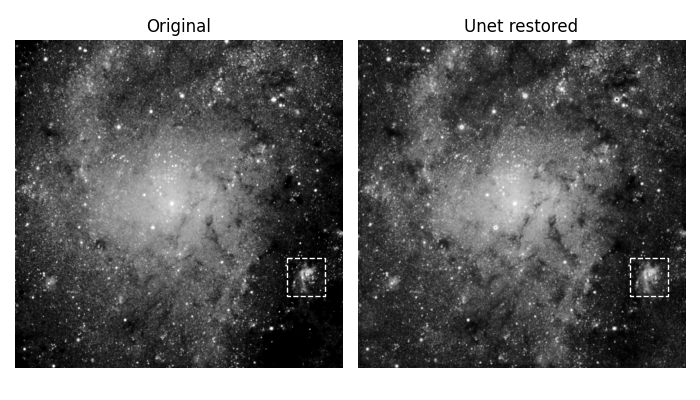

In [35]:
zscale = ZScaleInterval(contrast=.25)
# z1, z2 = zscale.get_limits(restored)
z1, z2 = zscale.get_limits(t2np(x))

# image_d(restored, mx=mx, my=my, mw=mxw, cmap='gray', vmin=z1, vmax=z2)   
# save_img(restored, './imgs/m33_2_restored.png', vmin=z1, vmax=z2, cmap='gray') 

fig, axs = plt.subplots(1, 2, figsize=(7, 4))
rect1 = patches.Rectangle((mx - mxw // 2, my - mxw // 2), 
                                 mxw, mxw, linewidth=1, 
                                 edgecolor='white', facecolor='none', 
                                 ls='--', fill=None)

rect2 = patches.Rectangle((mx - mxw // 2, my - mxw // 2), 
                                 mxw, mxw, linewidth=1, 
                                 edgecolor='white', facecolor='none', 
                                 ls='--', fill=None)

ax1 = axs[0]
ax1.add_patch(rect1)
ax1.imshow(x0s, cmap='gray', vmin=z1, vmax=z2) 
ax1.set_title('Original') 
ax1.axis('off') 

ax2 = axs[1]
ax2.add_patch(rect2)
ax2.imshow(unet_restored, cmap='gray', vmin=z1, vmax=z2)
ax2.set_title('Unet restored') 
ax2.axis('off') 

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Layout to prevent title overlap
plt.show()

(np.float64(-0.5), np.float64(119.5), np.float64(119.5), np.float64(-0.5))

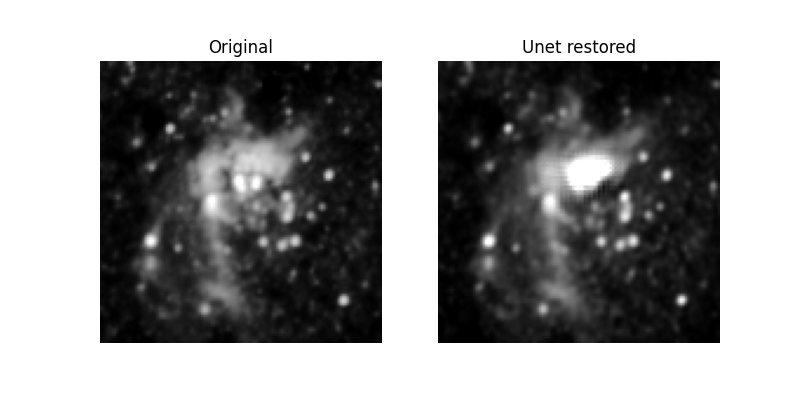

In [34]:
# ref_crop = t2np(y)[0, my-mxw//2:my+mxw//2, mx-mxw//2:mx+mxw//2]
restored_crop = bbdm_restored[my-mxw//2:my+mxw//2, mx-mxw//2:mx+mxw//2]
orig_crop = x0s[my-mxw//2:my+mxw//2, mx-mxw//2:mx+mxw//2]

fig, axs = plt.subplots(1, 2, figsize=(8, 4))

ax1 = axs[0]
ax1.imshow(orig_crop, cmap='gray', vmin=z1, vmax=z2) 
ax1.set_title('Original') 
ax1.axis('off') 

ax2 = axs[1]
ax2.imshow(restored_crop, cmap='gray', vmin=z1, vmax=z2)
ax2.set_title('Unet restored') 
ax2.axis('off') 

# image_d(ref_crop, vmin=ref_z1, vmax=ref_z2, cmap='gray', ws=4)
# save_img(ref_crop, './imgs/m33_2_ref_crop.png', vmin=ref_z1, vmax=ref_z2, cmap='gray') 